In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
run_name = "ch12_sft-lora"

data_dir = Path("data") / "ch12" / "sft-lora"
tsv = data_dir / "training.tsv"

In [3]:
df = pd.read_csv(tsv, sep='\t')
df = df.sort_values(by='step', ascending=True)
df = df.drop_duplicates(subset=['step', 'split'], keep='last')

train_df = df.loc[df['split'] == 'train', :]
eval_df = df.loc[df['split'] == 'eval', :]

df.nsmallest(10, 'loss')

,step,epoch,split,loss,learning_rate,created_at
27,950,21,train,4.839,0.0001,2025-11-11T07:51:55+08:00
28,1000,22,train,4.845,0.0001,2025-11-11T07:53:56+08:00
24,850,19,train,4.867,0.0001,2025-11-11T07:47:52+08:00
25,900,20,train,4.883,0.0001,2025-11-11T07:49:52+08:00
22,800,18,train,4.902,0.0001,2025-11-11T07:45:48+08:00
21,750,17,train,4.923,0.0001,2025-11-11T07:43:48+08:00
19,700,16,train,4.947,0.0001,2025-11-11T07:41:45+08:00
18,650,15,train,4.955,0.0001,2025-11-11T07:39:43+08:00
16,600,14,train,4.988,0.0001,2025-11-11T07:37:41+08:00
15,550,12,train,5.020,0.0001,2025-11-11T07:35:41+08:00


In [4]:
train_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
15,550,12,train,5.020,0.0001,2025-11-11T07:35:41+08:00
16,600,14,train,4.988,0.0001,2025-11-11T07:37:41+08:00
18,650,15,train,4.955,0.0001,2025-11-11T07:39:43+08:00
19,700,16,train,4.947,0.0001,2025-11-11T07:41:45+08:00
21,750,17,train,4.923,0.0001,2025-11-11T07:43:48+08:00
22,800,18,train,4.902,0.0001,2025-11-11T07:45:48+08:00
24,850,19,train,4.867,0.0001,2025-11-11T07:47:52+08:00
25,900,20,train,4.883,0.0001,2025-11-11T07:49:52+08:00
27,950,21,train,4.839,0.0001,2025-11-11T07:51:55+08:00
28,1000,22,train,4.845,0.0001,2025-11-11T07:53:56+08:00


In [5]:
eval_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
2,100,3,eval,8.974,NaN,2025-11-11T07:17:27+08:00
5,200,5,eval,8.614,NaN,2025-11-11T07:21:29+08:00
8,300,7,eval,8.513,NaN,2025-11-11T07:25:33+08:00
11,400,9,eval,8.374,NaN,2025-11-11T07:29:37+08:00
14,500,11,eval,8.403,NaN,2025-11-11T07:33:41+08:00
17,600,14,eval,8.389,NaN,2025-11-11T07:37:43+08:00
20,700,16,eval,8.363,NaN,2025-11-11T07:41:47+08:00
23,800,18,eval,8.326,NaN,2025-11-11T07:45:51+08:00
26,900,20,eval,8.293,NaN,2025-11-11T07:49:55+08:00
29,1000,22,eval,8.294,NaN,2025-11-11T07:53:59+08:00


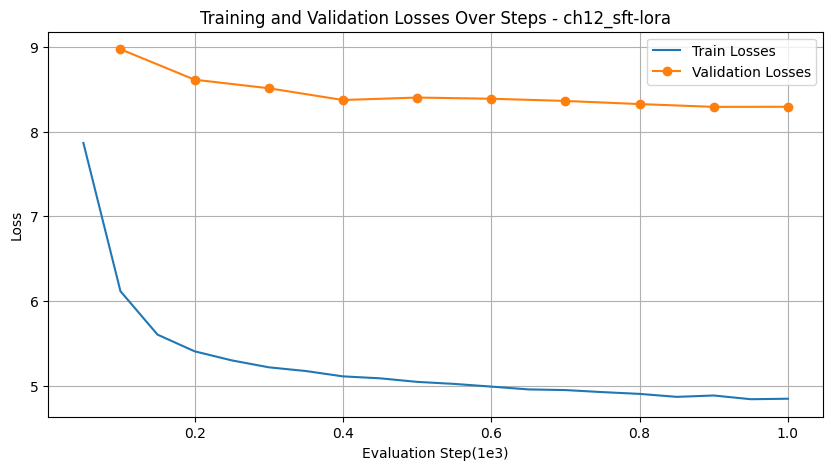

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['loss'], label="Train Losses")
plt.plot(eval_df['step']/1e3, eval_df['loss'], label="Validation Losses", marker='o')
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Loss")
#plt.xlim(0, max(1e6, df["step"].max()))

plt.title(f"Training and Validation Losses Over Steps - {run_name}")
plt.legend()
plt.grid()

#plt.show()
plt.savefig(data_dir / "training.pdf")

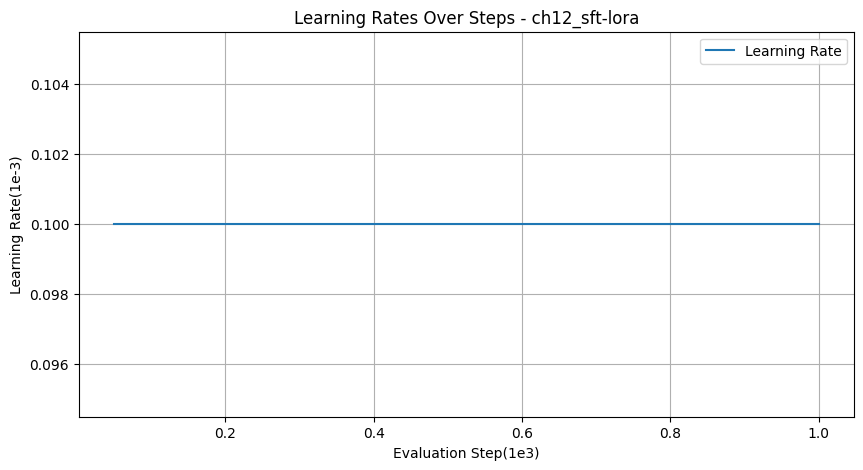

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['learning_rate']*1e3, label="Learning Rate")
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Learning Rate(1e-3)")
plt.title(f"Learning Rates Over Steps - {run_name}")
plt.legend()
plt.grid()
#plt.xlim(0, max(1e6, df["step"].max()))
#plt.show()
plt.savefig(data_dir / "learning_rate.pdf")